# Store Sales Time Series Forecasting
## An End-to-End Forecasting Project

### Business Context
Corporación Favorita is a large Ecuadorian grocery retailer operating 54 stores 
across multiple cities. Accurate sales forecasting helps the business make better 
inventory decisions, reduce waste, and optimize staffing. This project builds a 
time series forecasting model to predict future sales for a specific store and 
product family.

## Project Overview

This project follows a complete time series forecasting workflow:

1. Data Collection and Exploration
2. Data Cleaning and Transformation
3. Exploratory Data Analysis
4. Model Development
5. Model Optimization
6. Streamlit Web Application Deployment
7. Documentation and Version Control

## 1. Data Collection and Exploration
### 1.1 Importing Libraries

In [1]:
# Import core libraries for data manipulation
import pandas as pd
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


### 1.2 Loading the Datasets

In [2]:
# Load all datasets
train = pd.read_csv('train.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
oil = pd.read_csv('oil.csv', parse_dates=['date'])
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('transactions.csv', parse_dates=['date'])

print("All datasets loaded successfully")
print("Train shape:", train.shape)
print("Stores shape:", stores.shape)
print("Oil shape:", oil.shape)
print("Holidays shape:", holidays.shape)
print("Transactions shape:", transactions.shape)

All datasets loaded successfully
Train shape: (3000888, 6)
Stores shape: (54, 5)
Oil shape: (1218, 2)
Holidays shape: (350, 6)
Transactions shape: (83488, 3)


In [3]:
# Display the first few rows of each dataset
print("=== TRAIN ===")
print(train.head())
print("\n=== STORES ===")
print(stores.head())
print("\n=== OIL ===")
print(oil.head())
print("\n=== HOLIDAYS ===")
print(holidays.head())
print("\n=== TRANSACTIONS ===")
print(transactions.head())

=== TRAIN ===
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0

=== STORES ===
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4

=== OIL ===
        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20

==

In [4]:
# Check the date range of our training data
print("Train date range:")
print("Start:", train['date'].min())
print("End:", train['date'].max())
print("Total days:", (train['date'].max() - train['date'].min()).days)

print("\nUnique stores:", train['store_nbr'].nunique())
print("Unique product families:", train['family'].nunique())
print("\nProduct families:")
print(train['family'].unique())

Train date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00
Total days: 1687

Unique stores: 54
Unique product families: 33

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [5]:
# Check total sales by family to confirm GROCERY I is the highest
family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=False)
print("Top 10 product families by total sales:")
print(family_sales.head(10))

Top 10 product families by total sales:
family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64


In [6]:
# Filter data for Store 1 and GROCERY I
df = train[(train['store_nbr'] == 1) & (train['family'] == 'GROCERY I')].copy()

# Set date as index
df = df.set_index('date')

# Keep only relevant columns
df = df[['sales', 'onpromotion']]

print("Filtered dataset shape:", df.shape)
print("\nDate range:")
print("Start:", df.index.min())
print("End:", df.index.max())
print("\nFirst few rows:")
print(df.head())

Filtered dataset shape: (1684, 2)

Date range:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00

First few rows:
             sales  onpromotion
date                           
2013-01-01     0.0            0
2013-01-02  2652.0            0
2013-01-03  2121.0            0
2013-01-04  2056.0            0
2013-01-05  2216.0            0


### 1.3 Initial Data Exploration

In [7]:
# Basic information about our filtered dataset
print("=== DATASET INFO ===")
print(df.info())

print("\n=== STATISTICAL SUMMARY ===")
print(df.describe())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== ZERO SALES DAYS ===")
print("Number of days with zero sales:", (df['sales'] == 0).sum())
print("Percentage of zero sales days:", round((df['sales'] == 0).sum() / len(df) * 100, 2), "%")

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1684 entries, 2013-01-01 to 2017-08-15
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        1684 non-null   float64
 1   onpromotion  1684 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 39.5 KB
None

=== STATISTICAL SUMMARY ===
             sales  onpromotion
count  1684.000000  1684.000000
mean   2223.172803    17.560570
std     779.285352    24.741069
min       0.000000     0.000000
25%    1873.500000     0.000000
50%    2283.500000     6.000000
75%    2649.000000    28.000000
max    9065.000000   167.000000

=== MISSING VALUES ===
sales          0
onpromotion    0
dtype: int64

=== ZERO SALES DAYS ===
Number of days with zero sales: 6
Percentage of zero sales days: 0.36 %


In [8]:
# Identify zero sales days
zero_sales_days = df[df['sales'] == 0]
print("Days with zero sales:")
print(zero_sales_days)

Days with zero sales:
            sales  onpromotion
date                          
2013-01-01    0.0            0
2014-01-01    0.0            0
2015-01-01    0.0            0
2015-07-07    0.0            0
2016-01-01    0.0            0
2017-01-01    0.0            0


In [9]:
# Check if 2015-07-07 is in our holidays file
print(holidays[holidays['date'] == '2015-07-07'])

Empty DataFrame
Columns: [date, type, locale, locale_name, description, transferred]
Index: []


In [10]:
# Check for missing dates in our time series
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = full_date_range.difference(df.index)
print("Missing dates in time series:")
print(missing_dates)
print("Total missing dates:", len(missing_dates))

Missing dates in time series:
DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)
Total missing dates: 4


### 1.4 Checking Data Types

In [11]:
# Confirm date index is proper datetime type
print("Index type:", type(df.index))
print("Index dtype:", df.index.dtype)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nDate range confirmation:")
print("Start:", df.index.min())
print("End:", df.index.max())
print("Frequency:", pd.infer_freq(df.index))

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index dtype: datetime64[ns]

Column dtypes:
sales          float64
onpromotion      int64
dtype: object

Date range confirmation:
Start: 2013-01-01 00:00:00
End: 2017-08-15 00:00:00
Frequency: None


### 1.5 Exploration Summary

Key findings from initial exploration:

- Dataset covers 1,684 days from January 2013 to August 2017 for Store 1, GROCERY I
- Average daily sales are $2,223 with a maximum of $9,065
- 6 days have zero sales, all corresponding to store closure days
- 4 dates are completely missing from the dataset, all Christmas Days
- Time series frequency is irregular due to missing dates
- No missing values in sales or onpromotion columns
- Oil prices, holidays, and transactions data will be merged as additional features

## 2. Data Cleaning and Transformation
### 2.1 Handling Missing Dates

In [12]:
# Reindex to fill missing dates with NaN
df = df.reindex(full_date_range)

print("Shape after reindexing:", df.shape)
print("\nMissing values after reindexing:")
print(df.isnull().sum())
print("\nNew missing dates filled with NaN:")
print(df[df['sales'].isnull()])


Shape after reindexing: (1688, 2)

Missing values after reindexing:
sales          4
onpromotion    4
dtype: int64

New missing dates filled with NaN:
            sales  onpromotion
2013-12-25    NaN          NaN
2014-12-25    NaN          NaN
2015-12-25    NaN          NaN
2016-12-25    NaN          NaN


In [13]:
# Fill missing Christmas dates with 0 as stores were closed
df['sales'] = df['sales'].fillna(0)
df['onpromotion'] = df['onpromotion'].fillna(0)

print("Missing values after filling:")
print(df.isnull().sum())
print("\nShape:", df.shape)
print("\nChristmas dates after filling:")
print(df[df.index.month == 12][df[df.index.month == 12].index.day == 25])

Missing values after filling:
sales          0
onpromotion    0
dtype: int64

Shape: (1688, 2)

Christmas dates after filling:
            sales  onpromotion
2013-12-25    0.0          0.0
2014-12-25    0.0          0.0
2015-12-25    0.0          0.0
2016-12-25    0.0          0.0


### 2.2 Handling Zero Sales Days

In [14]:
# Instead of removing zero sales days, we will interpolate them
# Zero sales on holidays should be replaced with interpolated values
# so the model does not learn that sales drop to zero on these days

# Identify zero sales days
zero_days = df[df['sales'] == 0].index
print("Zero sales days:")
print(zero_days)

# Replace zeros with NaN temporarily for interpolation
df['sales'] = df['sales'].replace(0, np.nan)

# Interpolate using linear method
df['sales'] = df['sales'].interpolate(method='linear')

print("\nSales after interpolation on previously zero days:")
print(df.loc[zero_days, 'sales'])

Zero sales days:
DatetimeIndex(['2013-01-01', '2013-12-25', '2014-01-01', '2014-12-25',
               '2015-01-01', '2015-07-07', '2015-12-25', '2016-01-01',
               '2016-12-25', '2017-01-01'],
              dtype='datetime64[ns]', freq=None)

Sales after interpolation on previously zero days:
2013-01-01       NaN
2013-12-25    2544.0
2014-01-01    1965.5
2014-12-25    2704.0
2015-01-01    1743.0
2015-07-07    2262.5
2015-12-25    2373.0
2016-01-01    2044.5
2016-12-25    2256.5
2017-01-01    1993.0
Name: sales, dtype: float64


In [15]:
# 2013-01-01 is the first row so interpolation could not fill it
# We fill it with the next available value using bfill
df['sales'] = df['sales'].bfill()

print("Missing values remaining:")
print(df.isnull().sum())
print("\n2013-01-01 sales after backfill:")
print(df.loc['2013-01-01', 'sales'])

Missing values remaining:
sales          0
onpromotion    0
dtype: int64

2013-01-01 sales after backfill:
2652.0


### 2.3 Outlier Detection and Treatment

In [16]:
from scipy import stats

# Calculate Z-scores for sales
z_scores = np.abs(stats.zscore(df['sales']))

# Identify outliers beyond 3 standard deviations
outliers = df[z_scores > 3]
print("Number of outliers detected:", len(outliers))
print("\nOutlier dates and sales values:")
print(outliers['sales'].sort_values(ascending=False))

Number of outliers detected: 12

Outlier dates and sales values:
2016-04-18    9065.0
2016-04-19    8221.0
2016-04-20    5438.0
2016-12-23    5386.0
2016-12-21    5162.0
2016-12-22    5055.0
2017-03-07    4917.0
2016-04-22    4871.0
2016-04-21    4768.0
2016-11-09    4669.0
2016-12-13    4624.0
2017-06-20    4575.0
Name: sales, dtype: float64


In [17]:
# Cross reference outliers with holidays
print("Checking April 2016 in holidays file:")
print(holidays[(holidays['date'] >= '2016-04-15') & 
               (holidays['date'] <= '2016-04-25')])

print("\nChecking December 2016 in holidays file:")
print(holidays[(holidays['date'] >= '2016-12-20') & 
               (holidays['date'] <= '2016-12-25')])

Checking April 2016 in holidays file:
          date     type    locale locale_name                description  \
219 2016-04-16    Event  National     Ecuador           Terremoto Manabi   
220 2016-04-17    Event  National     Ecuador         Terremoto Manabi+1   
221 2016-04-18    Event  National     Ecuador         Terremoto Manabi+2   
222 2016-04-19    Event  National     Ecuador         Terremoto Manabi+3   
223 2016-04-20    Event  National     Ecuador         Terremoto Manabi+4   
224 2016-04-21  Holiday     Local    Riobamba  Cantonizacion de Riobamba   
225 2016-04-21    Event  National     Ecuador         Terremoto Manabi+5   
226 2016-04-22    Event  National     Ecuador         Terremoto Manabi+6   
227 2016-04-23    Event  National     Ecuador         Terremoto Manabi+7   
228 2016-04-24    Event  National     Ecuador         Terremoto Manabi+8   
229 2016-04-25    Event  National     Ecuador         Terremoto Manabi+9   

     transferred  
219        False  
220        

All 12 detected outliers were investigated and confirmed to be legitimate 
real world events. The April 2016 spike corresponds to the Manabi earthquake 
which caused panic buying of groceries. The December spikes correspond to 
pre-Christmas shopping. Removing these would reduce model accuracy so we 
retain them and instead add holiday and earthquake indicators as features 
during feature engineering.


### 2.4 Merging External Data

We merge daily oil prices into our dataset because Ecuador is an oil dependent 
economy. When oil prices drop, government revenue decreases, consumer purchasing 
power weakens, and grocery sales are affected. Oil price is therefore a strong 
external economic indicator for predicting sales.

In [18]:
# Merge oil prices into our main dataframe
df = df.merge(oil, left_index=True, right_on='date', how='left')
df = df.set_index('date')

print("Shape after merging oil:", df.shape)
print("\nMissing oil prices:")
print(df['dcoilwtico'].isnull().sum())

Shape after merging oil: (1688, 3)

Missing oil prices:
525


In [19]:
# Fill missing oil prices using forward fill
# This carries the last known price forward to weekends and holidays
df['dcoilwtico'] = df['dcoilwtico'].ffill()

# Check if any missing values remain
print("Missing oil prices after forward fill:", df['dcoilwtico'].isnull().sum())
print("\nOil price statistics:")
print(df['dcoilwtico'].describe())

Missing oil prices after forward fill: 1

Oil price statistics:
count    1687.000000
mean       67.893651
std        25.672864
min        26.190000
25%        46.375000
50%        53.410000
75%        95.720000
max       110.620000
Name: dcoilwtico, dtype: float64


In [20]:
# Check which date still has missing oil price
print("Remaining missing oil price date:")
print(df[df['dcoilwtico'].isnull()])

# Fill with backward fill since it is the first row
df['dcoilwtico'] = df['dcoilwtico'].bfill()

print("\nMissing oil prices after backfill:", df['dcoilwtico'].isnull().sum())

Remaining missing oil price date:
             sales  onpromotion  dcoilwtico
date                                       
2013-01-01  2652.0          0.0         NaN

Missing oil prices after backfill: 0


Oil prices were successfully merged. 525 missing values were found corresponding 
to weekends and holidays when oil markets are closed. These were filled using 
forward fill, carrying the last known price forward, which is the standard 
approach for financial time series data.

We create a binary holiday indicator for national holidays. Holidays significantly 
impact grocery sales, either causing spikes due to pre-holiday shopping or drops 
due to store closures. We focus on national holidays only since Store 1 is in 
Quito and national holidays apply to the entire country.

In [21]:
# Create a holiday indicator for national holidays only
national_holidays = holidays[holidays['locale'] == 'National'][['date', 'type', 'description']].copy()

# Create a binary holiday flag
national_holidays['is_holiday'] = 1

# Merge with our main dataframe
df = df.merge(national_holidays[['date', 'is_holiday']], 
              left_index=True, right_on='date', how='left')
df = df.set_index('date')

# Fill non-holiday days with 0
df['is_holiday'] = df['is_holiday'].fillna(0)

print("Shape after merging holidays:", df.shape)
print("Total holiday days in our dataset:", df['is_holiday'].sum())
print("\nSample holiday days:")
print(df[df['is_holiday'] == 1].head(10))

Shape after merging holidays: (1692, 4)
Total holiday days in our dataset: 151.0

Sample holiday days:
             sales  onpromotion  dcoilwtico  is_holiday
date                                                   
2013-01-01  2652.0          0.0       93.14         1.0
2013-01-05  2216.0          0.0       93.12         1.0
2013-01-12  1796.0          0.0       93.60         1.0
2013-02-11   458.0          0.0       97.01         1.0
2013-02-12   628.0          0.0       97.48         1.0
2013-04-29  1579.0          0.0       94.09         1.0
2013-05-01   966.0          0.0       90.74         1.0
2013-05-11  2244.0          0.0       95.81         1.0
2013-05-12   674.0          0.0       95.81         1.0
2013-05-24   650.0          0.0       93.84         1.0


In [22]:
# Check for duplicate dates caused by multiple holidays on same day
print("Shape before fix:", df.shape)
print("Duplicate dates:", df.index.duplicated().sum())

# Keep only one record per date by taking the maximum holiday flag
df = df.groupby(df.index).max()

print("Shape after fix:", df.shape)
print("Duplicate dates after fix:", df.index.duplicated().sum())

Shape before fix: (1692, 4)
Duplicate dates: 4
Shape after fix: (1688, 4)
Duplicate dates after fix: 0


151 national holiday days were identified in our dataset spanning from 2013 to 
2017. These include major Ecuadorian holidays like New Year, Easter, Christmas, 
and Independence Day. A binary flag of 1 indicates a holiday and 0 indicates 
a regular day.

We merge daily transaction counts for Store 1. Transactions represent the number 
of customers who visited the store on a given day. Higher transactions generally 
correlate with higher sales and provide additional context about store traffic patterns.

In [23]:
# Merge transactions for store 1 only
store1_transactions = transactions[transactions['store_nbr'] == 1][['date', 'transactions']].copy()

df = df.merge(store1_transactions, left_index=True, right_on='date', how='left')
df = df.set_index('date')

print("Shape after merging transactions:", df.shape)
print("\nMissing transactions:")
print(df['transactions'].isnull().sum())

Shape after merging transactions: (1688, 5)

Missing transactions:
12


In [24]:
# Fill missing transactions using forward fill
df['transactions'] = df['transactions'].ffill()

print("Missing transactions after forward fill:", df['transactions'].isnull().sum())
print("\nDataframe shape:", df.shape)
print("\nCurrent columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Missing transactions after forward fill: 1

Dataframe shape: (1688, 5)

Current columns: ['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions']

First few rows:
             sales  onpromotion  dcoilwtico  is_holiday  transactions
date                                                                 
2013-01-01  2652.0          0.0       93.14         1.0           NaN
2013-01-02  2652.0          0.0       93.14         0.0        2111.0
2013-01-03  2121.0          0.0       92.97         0.0        1833.0
2013-01-04  2056.0          0.0       93.12         0.0        1863.0
2013-01-05  2216.0          0.0       93.12         1.0        1509.0


In [25]:
# Fill the first row using backfill
df['transactions'] = df['transactions'].bfill()

print("Missing transactions after backfill:", df['transactions'].isnull().sum())
print("\n2013-01-01 transactions:")
print(df.loc['2013-01-01', 'transactions'])


Missing transactions after backfill: 0

2013-01-01 transactions:
2111.0


Transaction data for Store 1 was successfully merged. 12 missing values were 
filled using forward fill for weekends and holidays. Transactions range provides 
additional context about daily customer footfall which directly influences sales volume.

### 2.5 Feature Engineering

In [26]:
# Extract time based features from the date index
df['day_of_week'] = df.index.dayofweek
df['day_of_month'] = df.index.day
df['month'] = df.index.month
df['year'] = df.index.year
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['quarter'] = df.index.quarter
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

print("New features added:")
print(df.columns.tolist())
print("\nFirst few rows with new features:")
print(df.head())

New features added:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend']

First few rows with new features:
             sales  onpromotion  dcoilwtico  is_holiday  transactions  \
date                                                                    
2013-01-01  2652.0          0.0       93.14         1.0        2111.0   
2013-01-02  2652.0          0.0       93.14         0.0        2111.0   
2013-01-03  2121.0          0.0       92.97         0.0        1833.0   
2013-01-04  2056.0          0.0       93.12         0.0        1863.0   
2013-01-05  2216.0          0.0       93.12         1.0        1509.0   

            day_of_week  day_of_month  month  year  week_of_year  quarter  \
date                                                                        
2013-01-01            1             1      1  2013             1        1   
2013-01-02            2             2      1

### 2.6 Lag Features and Rolling Statistics

Lag features use past sales values as input features for predicting future sales. 
They directly capture the temporal dependency in our time series. Rolling statistics 
capture the recent trend and volatility in sales.

In [27]:
# Create lag features
df['lag_1'] = df['sales'].shift(1)    # Yesterday's sales
df['lag_7'] = df['sales'].shift(7)    # Sales from 7 days ago
df['lag_14'] = df['sales'].shift(14)  # Sales from 14 days ago
df['lag_30'] = df['sales'].shift(30)  # Sales from 30 days ago
df['lag_365'] = df['sales'].shift(365) # Sales from same day last year

# Create rolling statistics
df['rolling_mean_7'] = df['sales'].shift(1).rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].shift(1).rolling(window=30).mean()
df['rolling_std_7'] = df['sales'].shift(1).rolling(window=7).std()

print("Columns after adding lag features:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nMissing values after lag features:")
print(df.isnull().sum())

Columns after adding lag features:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']

Shape: (1688, 20)

Missing values after lag features:
sales                0
onpromotion          0
dcoilwtico           0
is_holiday           0
transactions         0
day_of_week          0
day_of_month         0
month                0
year                 0
week_of_year         0
quarter              0
is_weekend           0
lag_1                1
lag_7                7
lag_14              14
lag_30              30
lag_365            365
rolling_mean_7       7
rolling_mean_30     30
rolling_std_7        7
dtype: int64


Lag features and rolling statistics were successfully created. Missing values 
in lag features are expected since the first N rows have no historical data 
to look back at. These rows will be dropped before model training. Our final 
feature set has 20 columns capturing temporal dependencies, external factors, 
and seasonal patterns.

### 2.7 Final Data Cleaning Verification

In [28]:
# Drop rows with missing lag values
df_clean = df.dropna()

print("Shape before dropping NaN:", df.shape)
print("Shape after dropping NaN:", df_clean.shape)
print("Rows dropped:", df.shape[0] - df_clean.shape[0])
print("\nMissing values in clean dataset:")
print(df_clean.isnull().sum().sum())
print("\nDate range of clean dataset:")
print("Start:", df_clean.index.min())
print("End:", df_clean.index.max())
print("\nFinal columns:")
print(df_clean.columns.tolist())

Shape before dropping NaN: (1688, 20)
Shape after dropping NaN: (1323, 20)
Rows dropped: 365

Missing values in clean dataset:
0

Date range of clean dataset:
Start: 2014-01-01 00:00:00
End: 2017-08-15 00:00:00

Final columns:
['sales', 'onpromotion', 'dcoilwtico', 'is_holiday', 'transactions', 'day_of_week', 'day_of_month', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_365', 'rolling_mean_7', 'rolling_mean_30', 'rolling_std_7']


After dropping rows with missing lag values, our clean dataset contains 1,323 
daily records from January 2014 to August 2017 with 20 features and zero 
missing values. The first year of data was removed because lag_365 requires 
a full year of historical sales to calculate. This clean dataset is now ready 
for exploratory data analysis and model development.

## 3. Exploratory Data Analysis

In this section we visualize the sales data to understand trends, seasonality, 
and patterns. EDA guides our model selection and feature engineering decisions 
by revealing the underlying structure of the time series.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("Visualization libraries imported successfully")

Visualization libraries imported successfully


### 3.1 Sales Trend Over Time

The overall sales trend shows us whether sales are growing, declining, or 
remaining stable over our entire date range. This helps us understand the 
long term direction of the business.

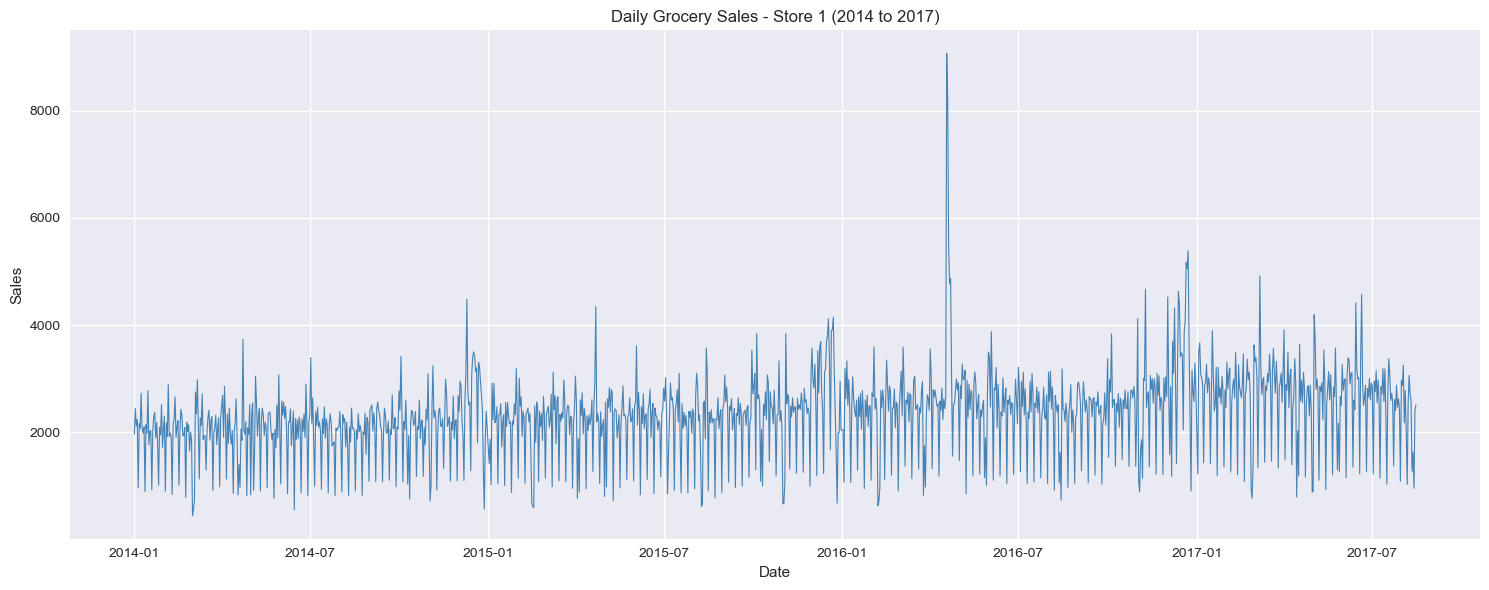

In [30]:
plt.figure(figsize=(15, 6))
plt.plot(df_clean.index, df_clean['sales'], color='steelblue', linewidth=0.8)
plt.title('Daily Grocery Sales - Store 1 (2014 to 2017)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()


The sales trend shows relatively stable daily sales between $1,500 and $3,500 
with a notable spike in April 2016 corresponding to the Manabi earthquake. 
Regular weekly oscillations confirm strong weekly seasonality. Sales volatility 
appears to increase slightly from 2016 onwards suggesting changing business 
conditions or increased promotional activity.

### 3.2 Monthly Sales Pattern

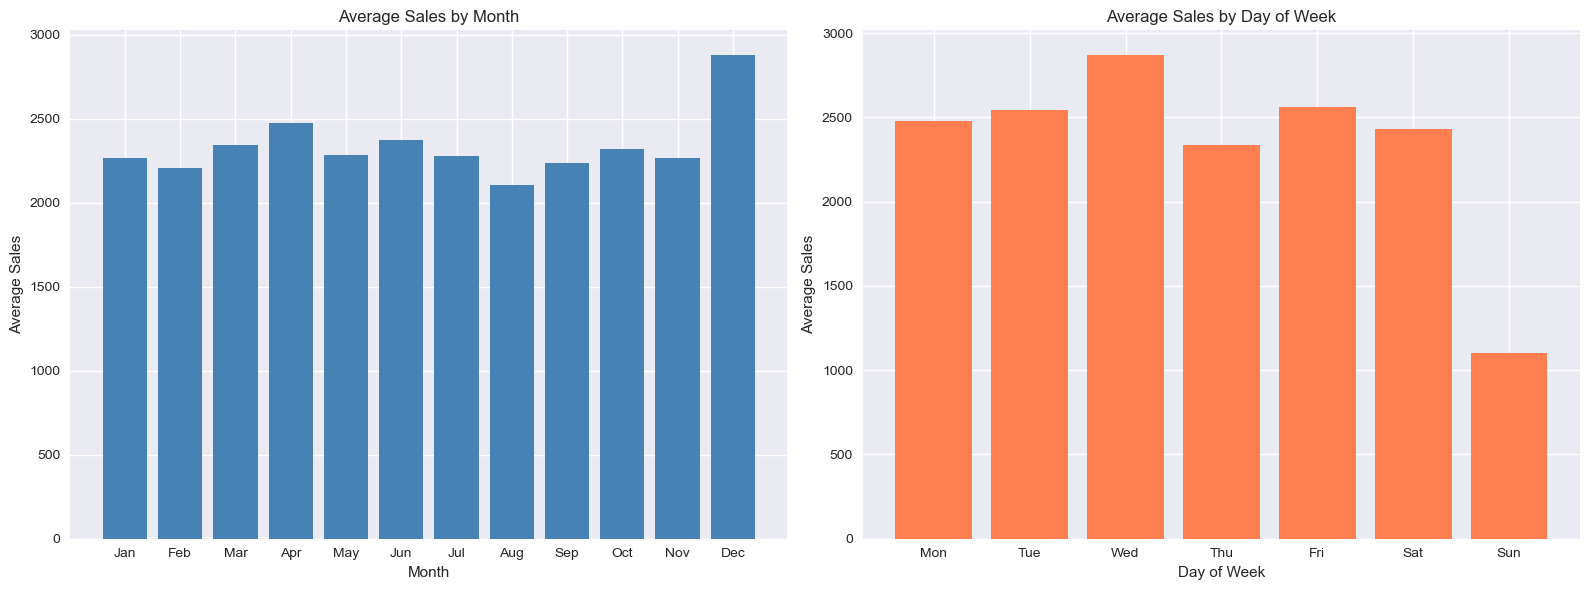

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average sales by month
monthly_sales = df_clean.groupby('month')['sales'].mean()
axes[0].bar(monthly_sales.index, monthly_sales.values, color='steelblue')
axes[0].set_title('Average Sales by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Average sales by day of week
daily_sales = df_clean.groupby('day_of_week')['sales'].mean()
axes[1].bar(daily_sales.index, daily_sales.values, color='coral')
axes[1].set_title('Average Sales by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Sales')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()

Monthly analysis shows December as the peak sales month due to Christmas shopping 
while February is the slowest. Weekly analysis reveals Wednesday as the highest 
sales day and Sunday as dramatically the lowest with sales dropping to nearly 
half the weekly average. These strong seasonal patterns confirm that day of week 
and month are critical features for our forecasting model.

### 3.3 Seasonal Decomposition

Seasonal decomposition separates our time series into three components. 
Trend shows the long term direction of sales. Seasonality shows recurring 
patterns at fixed intervals. Residual shows what remains after removing 
trend and seasonality, essentially the noise in the data.

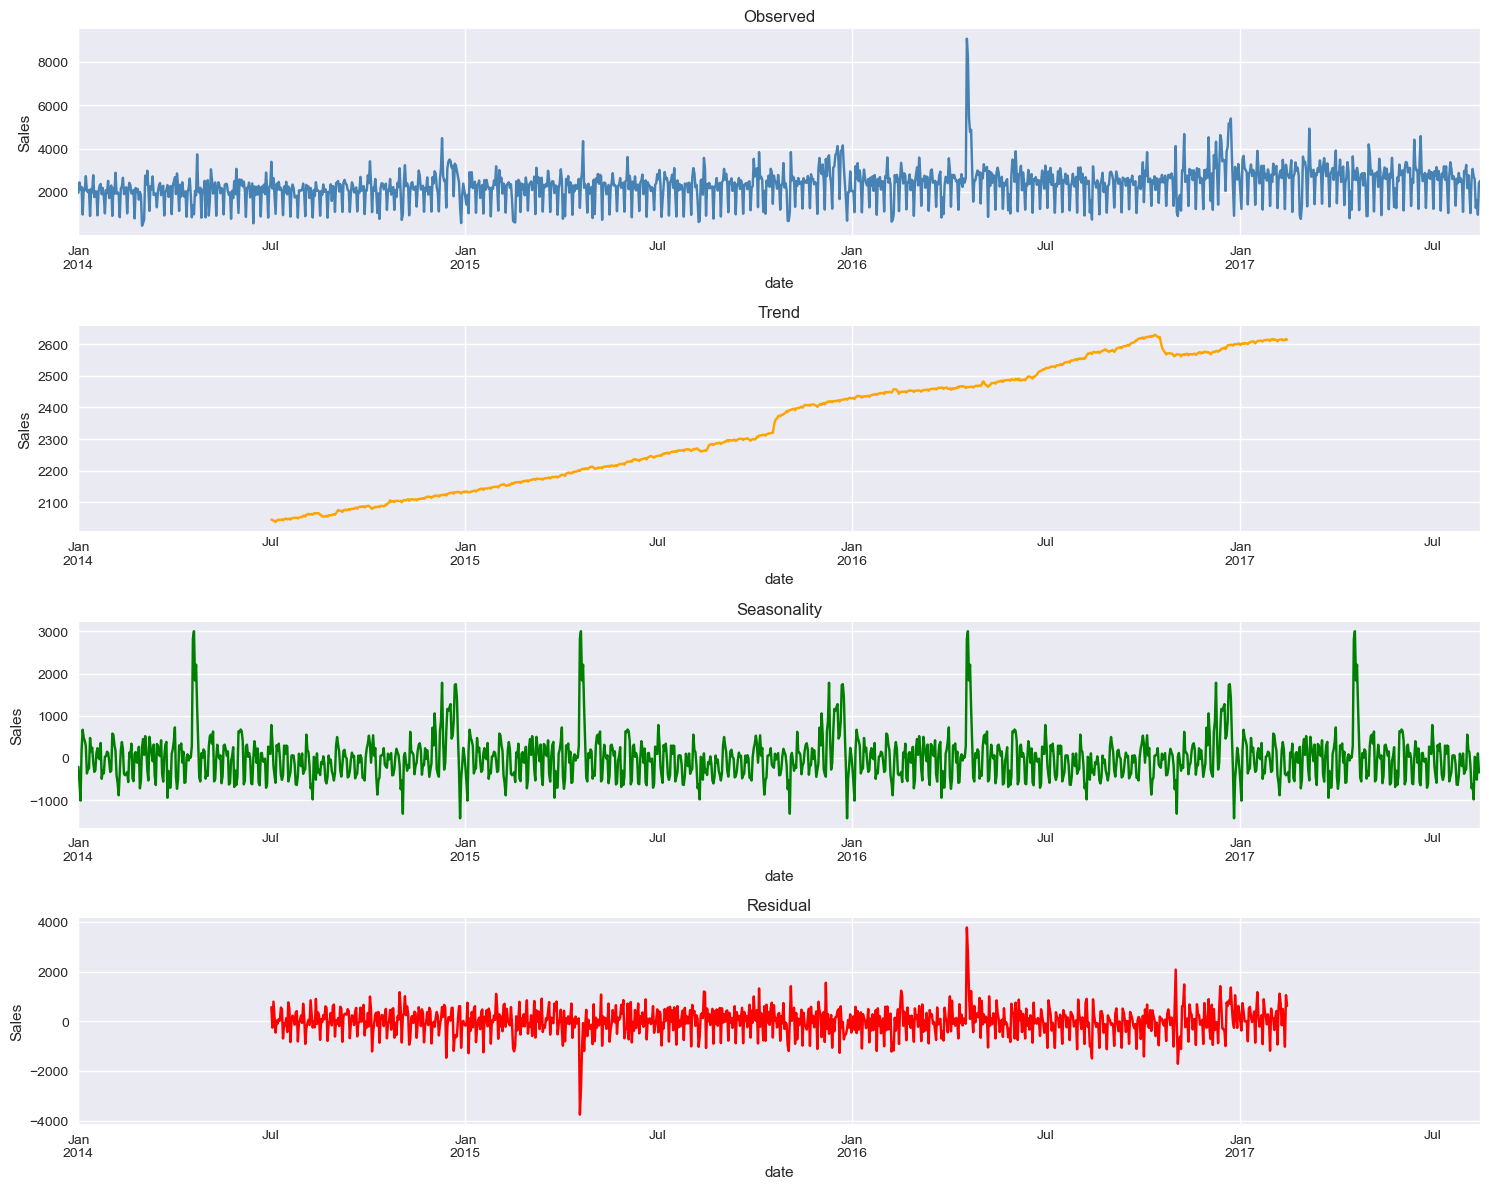

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(df_clean['sales'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

decomposition.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Observed')
axes[0].set_ylabel('Sales')

decomposition.trend.plot(ax=axes[1], color='orange')
axes[1].set_title('Trend')
axes[1].set_ylabel('Sales')

decomposition.seasonal.plot(ax=axes[2], color='green')
axes[2].set_title('Seasonality')
axes[2].set_ylabel('Sales')

decomposition.resid.plot(ax=axes[3], color='red')
axes[3].set_title('Residual')
axes[3].set_ylabel('Sales')

plt.tight_layout()
plt.show()

Seasonal decomposition reveals three key insights. First, there is a clear 
upward trend in sales from 2014 to 2016 indicating business growth. Second, 
strong annual seasonality is confirmed with consistent holiday spikes every 
year. Third, the residual component shows mostly random noise except for the 
April 2016 earthquake spike, confirming our data cleaning was effective. 
These findings guide our model selection toward approaches that can handle 
both trend and seasonality.

### 3.4 Stationarity Test

Stationarity is a critical property for time series modeling. A stationary 
time series has constant mean, variance, and autocorrelation over time. 
Most classical forecasting models like ARIMA require the series to be 
stationary. We use the Augmented Dickey Fuller test to check stationarity.

In [33]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(df_clean['sales'])

print("Augmented Dickey-Fuller Test Results:")
print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

if result[1] < 0.05:
    print("\nConclusion: Series is STATIONARY (p-value < 0.05)")
else:
    print("\nConclusion: Series is NON-STATIONARY (p-value >= 0.05)")

Augmented Dickey-Fuller Test Results:
ADF Statistic: -4.6092
p-value: 0.0001
Critical Values:
   1%: -3.4354
   5%: -2.8638
   10%: -2.568

Conclusion: Series is STATIONARY (p-value < 0.05)


The Augmented Dickey-Fuller test confirms that our sales series is stationary 
with a p-value of 0.0001, well below the 0.05 significance threshold. The ADF 
statistic of -4.6092 is more negative than all critical values confirming no 
unit root exists. This means we do not need to apply differencing and our series 
is ready for direct modeling with ARIMA and other forecasting algorithms.

### 3.5 Autocorrelation Analysis

Autocorrelation measures how correlated the series is with its own past values. 
The ACF plot shows correlations at different lag intervals. The PACF plot shows 
partial correlations removing the effect of intermediate lags. These plots help 
us determine the optimal parameters for our ARIMA model.

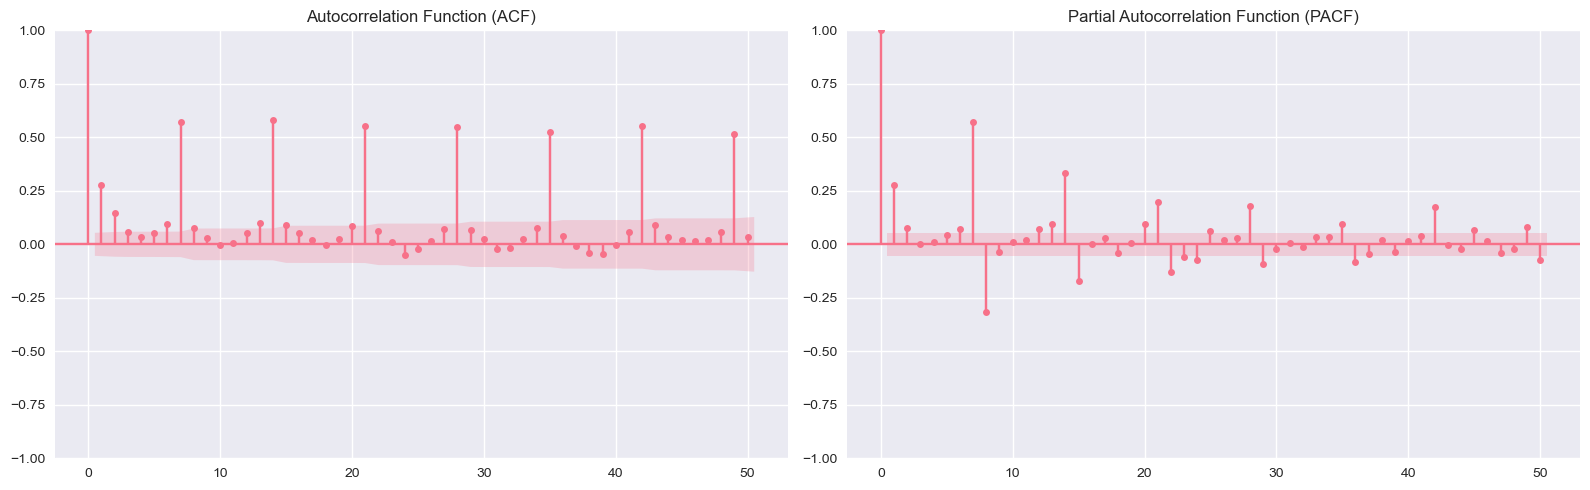

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df_clean['sales'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df_clean['sales'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

The ACF plot reveals significant autocorrelations at lags 7, 14, 21, 28 and 
beyond, all multiples of 7, confirming strong weekly seasonality in our sales 
data. The PACF shows significant spikes at lags 1 and 7. These findings indicate 
that a SARIMA model with a seasonal period of 7 is more appropriate than a 
simple ARIMA model. The weekly shopping patterns of grocery customers are clearly 
captured in these autocorrelation structures.

### 3.6 Sales vs Oil Price and Promotions

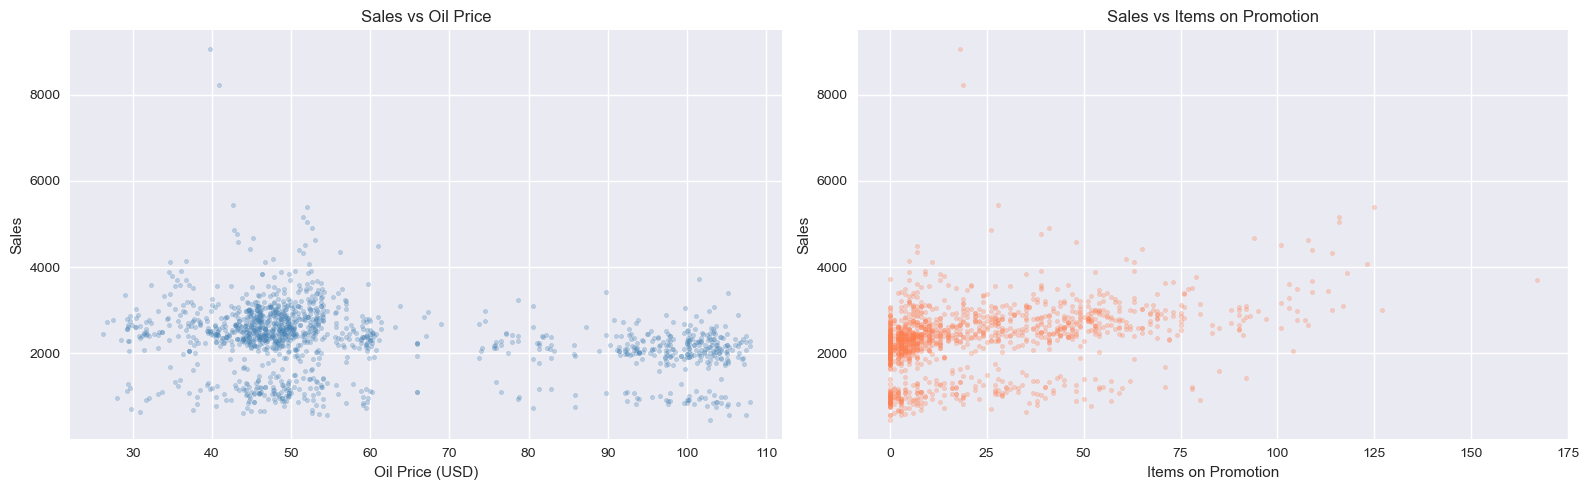

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sales vs Oil Price
axes[0].scatter(df_clean['dcoilwtico'], df_clean['sales'], 
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Sales vs Oil Price')
axes[0].set_xlabel('Oil Price (USD)')
axes[0].set_ylabel('Sales')

# Sales vs Promotions
axes[1].scatter(df_clean['onpromotion'], df_clean['sales'], 
                alpha=0.3, color='coral', s=10)
axes[1].set_title('Sales vs Items on Promotion')
axes[1].set_xlabel('Items on Promotion')
axes[1].set_ylabel('Sales')

plt.tight_layout()
plt.show()

The scatter plots reveal that oil price does not have a strong direct linear 
relationship with daily sales but lower oil prices correspond to higher sales 
volatility. Promotions show a weak positive relationship with sales, suggesting 
they contribute to higher sales but are not the primary driver. Both features 
will be retained as they provide additional context for the model even without 
strong linear relationships.

### 3.7 EDA Summary

Key insights from Exploratory Data Analysis:

1. Sales show a clear upward trend from 2014 to 2016 indicating business growth
2. Strong weekly seasonality confirmed with Wednesday highest and Sunday lowest
3. December is the peak sales month due to Christmas shopping
4. Annual seasonality confirmed with consistent holiday spikes every year
5. Series is stationary confirmed by ADF test with p-value of 0.0001
6. ACF and PACF reveal strong weekly autocorrelation at multiples of lag 7
7. SARIMA with seasonal period of 7 is recommended over simple ARIMA
8. The April 2016 earthquake caused the largest sales spike in our dataset
9. Oil prices and promotions have weak but non-zero relationships with sales

## 4. Model Development

Based on our EDA findings, we will train three forecasting models and compare 
their performance:

1. SARIMA - Seasonal ARIMA which handles both trend and weekly seasonality
2. Prophet - Facebook's forecasting library designed for business time series
3. XGBoost - A powerful machine learning approach using our engineered features

Each model brings a different perspective to the forecasting problem. SARIMA 
is the classical statistical approach. Prophet is designed specifically for 
business forecasting with holidays and seasonality. XGBoost leverages all 
our engineered features including lag variables and external factors.

### 4.1 Train Test Split

For time series data we cannot split randomly like we did in the house price 
project. We must respect the temporal order of the data. Training data must 
always come before test data. We use the last 90 days as our test set and 
everything before that as training data. This simulates a real world scenario 
where we train on historical data and forecast the future.

In [36]:
# Split data respecting temporal order
# Use last 90 days as test set
test_size = 90

train_data = df_clean.iloc[:-test_size]
test_data = df_clean.iloc[-test_size:]

print("Training set:")
print("Start:", train_data.index.min())
print("End:", train_data.index.max())
print("Size:", len(train_data), "days")

print("\nTest set:")
print("Start:", test_data.index.min())
print("End:", test_data.index.max())
print("Size:", len(test_data), "days")

Training set:
Start: 2014-01-01 00:00:00
End: 2017-05-17 00:00:00
Size: 1233 days

Test set:
Start: 2017-05-18 00:00:00
End: 2017-08-15 00:00:00
Size: 90 days


### 4.2 Evaluation Metrics

We will use three metrics to evaluate our models:

MAPE (Mean Absolute Percentage Error) measures the average percentage difference 
between predicted and actual values. It is easy to interpret as a percentage.

RMSE (Root Mean Squared Error) measures the average magnitude of errors. 
It penalizes large errors more heavily than small ones.

MAE (Mean Absolute Error) measures the average absolute difference between 
predicted and actual values. It is robust to outliers.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"\n{model_name} Performance:")
    print(f"MAE:  {round(mae, 2)}")
    print(f"RMSE: {round(rmse, 2)}")
    print(f"MAPE: {round(mape, 2)}%")
    
    return {'Model': model_name, 'MAE': round(mae, 2), 
            'RMSE': round(rmse, 2), 'MAPE': round(mape, 2)}

print("Evaluation function defined successfully")

Evaluation function defined successfully
